# Análise Exploratória de Dados — Preços de Carros no Brasil

Notebook preparado para o exercício com a base `precos_carros_brasil.csv`.

## Tarefas
a. Carregar a base
b. Verificar valores faltantes e aplicar tratativa
c. Verificar dados duplicados
d. Separar colunas numéricas e categóricas e imprimir estatísticas descritivas
e. Imprimir contagem de valores por `model` e `brand`
f. Apresentar uma breve explicação final sobre os principais resultados


In [38]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 120)


In [39]:
# a) Carregar a base
arquivo = 'precos_carros_brasil.csv'
df = pd.read_csv(arquivo)

print('Base carregada com sucesso.')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
display(df.head())


C:\Users\ths\AppData\Local\Temp\ipykernel_15076\4286628314.py:3: DtypeWarning: Columns (0: month_of_reference, 1: fipe_code, 2: authentication, 3: brand, 4: model, 5: fuel, 6: gear, 7: engine_size) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo)


Base carregada com sucesso.
Linhas: 267542 | Colunas: 11


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021.0,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002.0,9162.0
1,2021.0,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001.0,8832.0
2,2021.0,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000.0,8388.0
3,2021.0,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000.0,8453.0
4,2021.0,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001.0,12525.0


In [40]:
# Visão geral da estrutura da base
print('Informações gerais da base:')
df.info()


Informações gerais da base:
<class 'pandas.DataFrame'>
RangeIndex: 267542 entries, 0 to 267541
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   year_of_reference   202297 non-null  float64
 1   month_of_reference  202297 non-null  str    
 2   fipe_code           202297 non-null  str    
 3   authentication      202297 non-null  str    
 4   brand               202297 non-null  str    
 5   model               202297 non-null  str    
 6   fuel                202297 non-null  str    
 7   gear                202297 non-null  str    
 8   engine_size         202297 non-null  str    
 9   year_model          202297 non-null  float64
 10  avg_price_brl       202297 non-null  float64
dtypes: float64(3), str(8)
memory usage: 22.5 MB


In [41]:
# b) Verificar valores faltantes
faltantes = df.isnull().sum()
faltantes_percentual = (df.isnull().mean() * 100).round(2)

resumo_faltantes = pd.DataFrame({
    'qtd_faltantes': faltantes,
    'percentual_faltantes': faltantes_percentual
}).sort_values(by='qtd_faltantes', ascending=False)

print('Resumo de valores faltantes:')
display(resumo_faltantes)


Resumo de valores faltantes:


,qtd_faltantes,percentual_faltantes
year_of_reference,65245,24.39
month_of_reference,65245,24.39
fipe_code,65245,24.39
authentication,65245,24.39
brand,65245,24.39
model,65245,24.39
fuel,65245,24.39
gear,65245,24.39
engine_size,65245,24.39
year_model,65245,24.39


In [42]:
# Tratativa de valores faltantes
# Estratégia:
# - Colunas categóricas: preencher com 'Nao informado'
# - Colunas numéricas: preencher com a mediana

df_tratado = df.copy()

colunas_numericas = df_tratado.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()

for col in colunas_numericas:
    if df_tratado[col].isnull().sum() > 0:
        df_tratado[col] = df_tratado[col].fillna(df_tratado[col].median())

for col in colunas_categoricas:
    if df_tratado[col].isnull().sum() > 0:
        df_tratado[col] = df_tratado[col].fillna('Nao informado')

print('Valores faltantes após tratamento:')
display(df_tratado.isnull().sum())


C:\Users\ths\AppData\Local\Temp\ipykernel_15076\3231632065.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()


Valores faltantes após tratamento:


year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
brand                 0
model                 0
fuel                  0
gear                  0
engine_size           0
year_model            0
avg_price_brl         0
dtype: int64

In [43]:
# c) Verificar dados duplicados
qtd_duplicados = df_tratado.duplicated().sum()
print(f'Quantidade de linhas duplicadas: {qtd_duplicados}')

if qtd_duplicados > 0:
    df_tratado = df_tratado.drop_duplicates().reset_index(drop=True)
    print('Duplicados removidos com sucesso.')
else:
    print('Não há duplicados para remover.')

print(f'Nova dimensão da base: {df_tratado.shape}')


Quantidade de linhas duplicadas: 65246
Duplicados removidos com sucesso.
Nova dimensão da base: (202296, 11)


In [44]:
# d) Separar colunas numéricas e categóricas
colunas_numericas = df_tratado.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()

print('Colunas numéricas:')
print(colunas_numericas)
print('\nColunas categóricas:')
print(colunas_categoricas)


Colunas numéricas:
['year_of_reference', 'year_model', 'avg_price_brl']

Colunas categóricas:
['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']


C:\Users\ths\AppData\Local\Temp\ipykernel_15076\4045194084.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_tratado.select_dtypes(include=['object', 'category']).columns.tolist()


In [45]:
# Estatística descritiva das variáveis numéricas
print('Resumo estatístico das variáveis numéricas:')
display(df_tratado[colunas_numericas].describe())


Resumo estatístico das variáveis numéricas:


,year_of_reference,year_model,avg_price_brl
count,202296.000000,202296.000000,202296.000000
mean,2021.564697,2011.271518,52756.692901
std,0.571903,6.376225,51628.794894
min,2021.000000,2000.000000,6647.000000
25%,2021.000000,2006.000000,22855.000000
50%,2022.000000,2012.000000,38027.000000
75%,2022.000000,2016.000000,64064.000000
max,2023.000000,2023.000000,979358.000000


In [46]:
# Estatística descritiva das variáveis categóricas
print('Resumo estatístico das variáveis categóricas:')
display(df_tratado[colunas_categoricas].describe())


Resumo estatístico das variáveis categóricas:


,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size
count,202296,202296,202296,202296,202296,202296,202296,202296
unique,13,2092,202296,7,2113,4,3,30
top,January,001216-5,cfzlctzfwrcp,Fiat,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,Gasoline,manual,"1,6"
freq,24260,425,1,44962,425,168684,161883,47420


In [47]:
# e) Contagem de valores por modelo e marca
contagem_modelo = df_tratado['model'].value_counts().reset_index()
contagem_modelo.columns = ['model', 'quantidade']

contagem_marca = df_tratado['brand'].value_counts().reset_index()
contagem_marca.columns = ['brand', 'quantidade']

print('Contagem por modelo:')
display(contagem_modelo)

print('Contagem por marca:')
display(contagem_marca)


Contagem por modelo:


,model,quantidade
0,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,425
1,Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p,425
2,Focus 2.0 16V/SE/SE Plus Flex 5p Aut.,400
3,Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V,400
4,"Corvette 5.7/ 6.0, 6.2 Targa/Stingray",375
...,...,...
2108,Saveiro Robust 1.6 Total Flex 16V CD,2
2109,Saveiro Robust 1.6 Total Flex 16V,2
2110,Gol Last Edition 1.0 Flex 12V 5p,2
2111,Polo Track 1.0 Flex 12V 5p,2


Contagem por marca:


,brand,quantidade
0,Fiat,44962
1,VW - VolksWagen,44312
2,GM - Chevrolet,38590
3,Ford,33150
4,Renault,29191
5,Nissan,12090
6,Nao informado,1


In [48]:
# f) Breve explicação final
print('Resumo final da análise:')
print('A base foi carregada e inspecionada quanto a valores faltantes e duplicados.')
print('Os valores ausentes foram tratados com mediana nas variáveis numéricas e com "Nao informado" nas categóricas.')
print('Também foram identificadas as distribuições das variáveis numéricas e categóricas, além da frequência por modelo e marca.')
print('Essas análises ajudam a entender a composição da base e a preparar os dados para análises futuras.')


Resumo final da análise:
A base foi carregada e inspecionada quanto a valores faltantes e duplicados.
Os valores ausentes foram tratados com mediana nas variáveis numéricas e com "Nao informado" nas categóricas.
Também foram identificadas as distribuições das variáveis numéricas e categóricas, além da frequência por modelo e marca.
Essas análises ajudam a entender a composição da base e a preparar os dados para análises futuras.


## 2 Visualização dos dados

A partir da base de dados `precos_carros_brasil.csv`, execute as seguintes tarefas: 


**a.** Gere um gráfico da distribuição da quantidade de carros por marca.

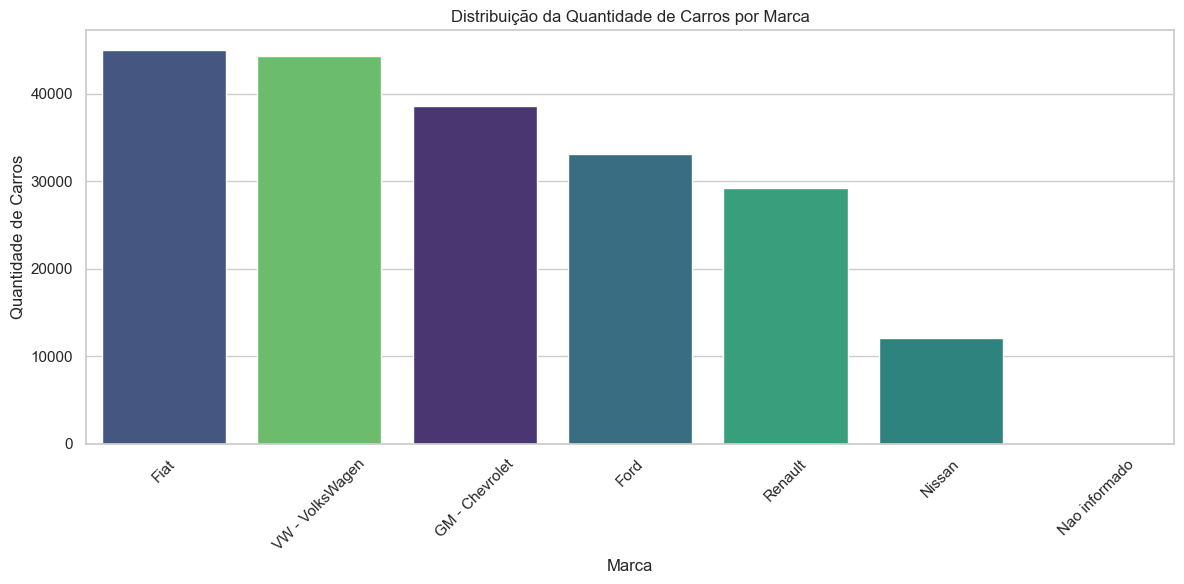

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.countplot(data=df_tratado, x='brand', hue='brand', order=df_tratado['brand'].value_counts().index, palette='viridis', legend=False)
plt.title('Distribuição da Quantidade de Carros por Marca')
plt.xlabel('Marca')
plt.ylabel('Quantidade de Carros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**b.** Gere um gráfico da distribuição da quantidade de carros por tipo de engrenagem do carro.



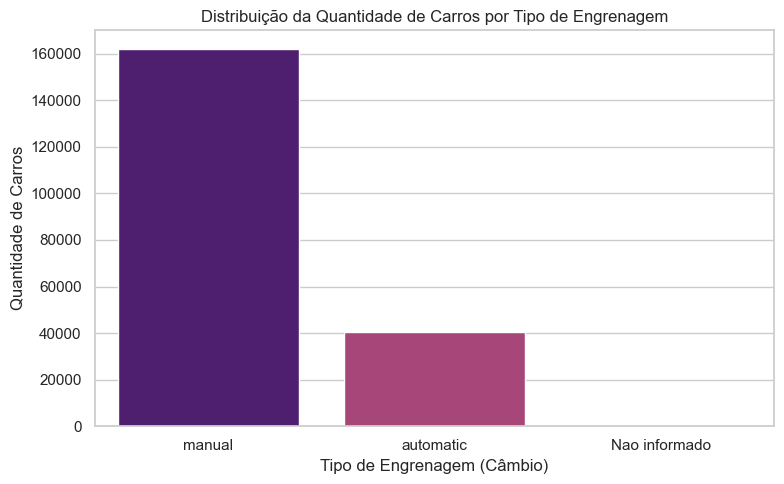

In [50]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_tratado, x='gear', hue='gear', order=df_tratado['gear'].value_counts().index, palette='magma', legend=False)
plt.title('Distribuição da Quantidade de Carros por Tipo de Engrenagem')
plt.xlabel('Tipo de Engrenagem (Câmbio)')
plt.ylabel('Quantidade de Carros')
plt.tight_layout()
plt.show()

**c.** Gere um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022 (variável de tempo no eixo X).

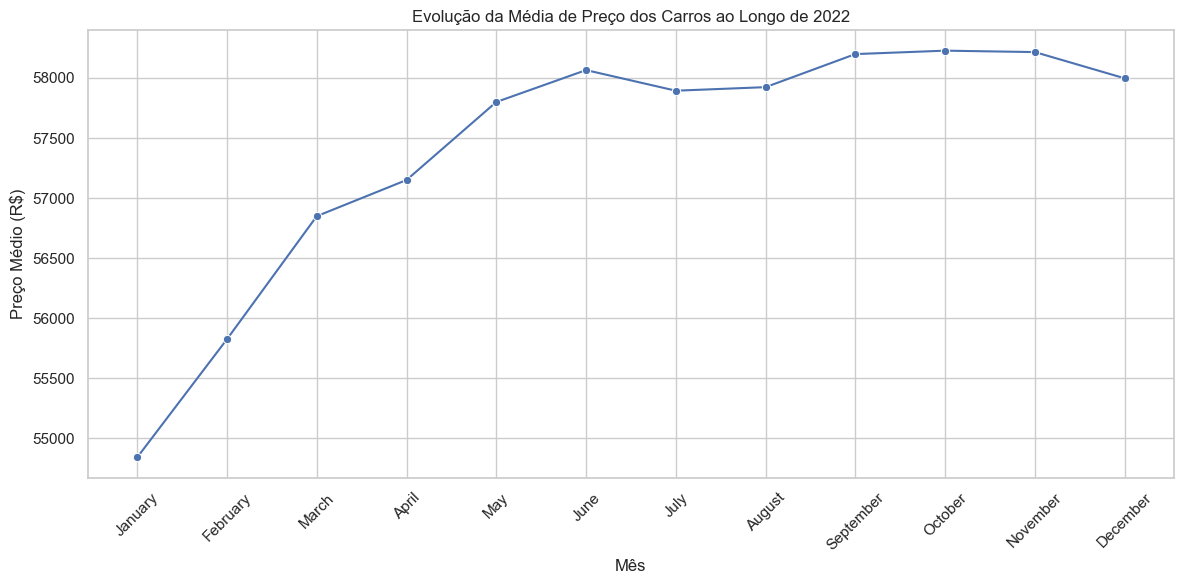

In [51]:
filtro_2022 = (df_tratado['year_of_reference'] == 2022) & (df_tratado['month_of_reference'] != 'Nao informado')
df_2022 = df_tratado[filtro_2022].copy()

meses_ordem = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

df_2022['month_of_reference'] = pd.Categorical(df_2022['month_of_reference'], categories=meses_ordem, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_2022, x='month_of_reference', y='avg_price_brl', errorbar=None, marker='o', color='b')
plt.title('Evolução da Média de Preço dos Carros ao Longo de 2022')
plt.xlabel('Mês')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**d.** Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de engrenagem.

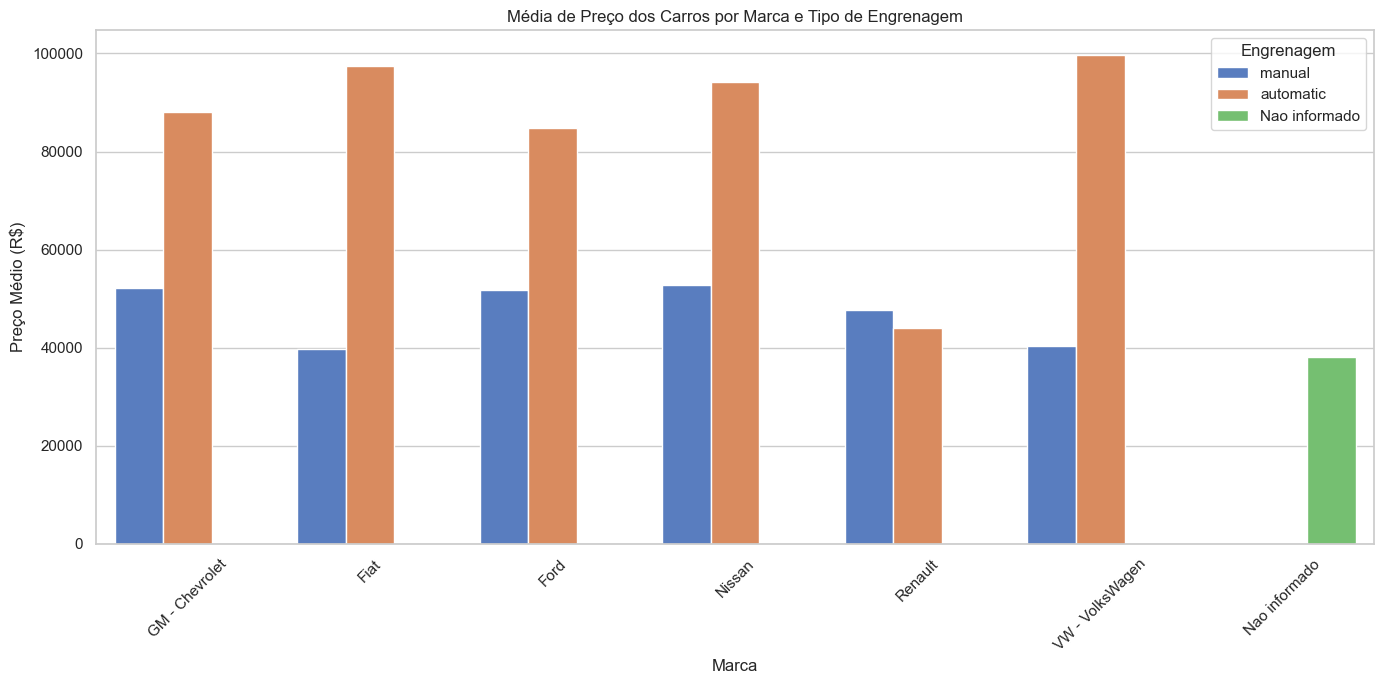

In [52]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_tratado, x='brand', y='avg_price_brl', hue='gear', errorbar=None, palette='muted')
plt.title('Média de Preço dos Carros por Marca e Tipo de Engrenagem')
plt.xlabel('Marca')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.legend(title='Engrenagem')
plt.tight_layout()
plt.show()

**e.** Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no item d.

Os gráficos indicam que, em todas as marcas analisadas, os veículos com câmbio automático apresentam um preço médio consideravelmente superior aos de câmbio manual. Isso reflete o maior valor agregado dessa tecnologia e sua maior presença em categorias de veículos premium ou modelos mais completos no mercado.

**f.** Gere um gráfico da distribuição da média de preço dos carros por marca e tipo de combustível.

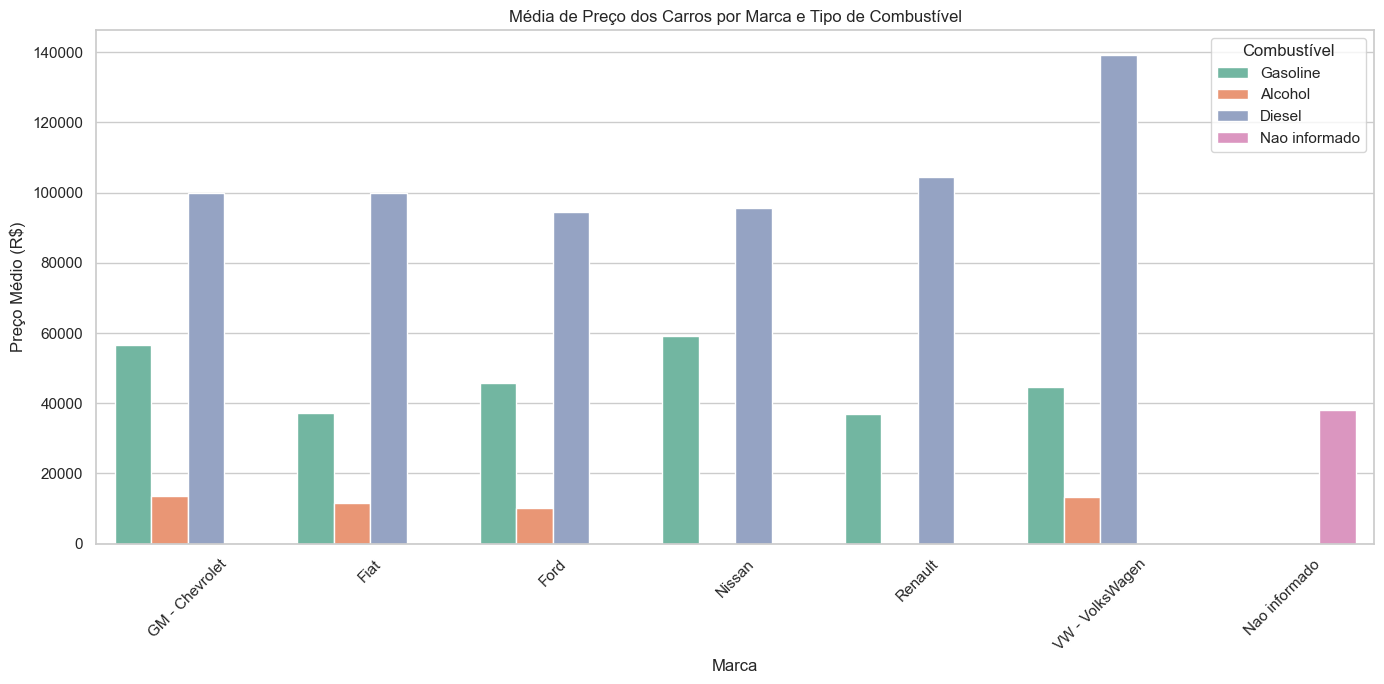

In [53]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_tratado, x='brand', y='avg_price_brl', hue='fuel', errorbar=None, palette='Set2')
plt.title('Média de Preço dos Carros por Marca e Tipo de Combustível')
plt.xlabel('Marca')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45)
plt.legend(title='Combustível')
plt.tight_layout()
plt.show()

**g.** Dê uma breve explicação (máximo de quatro linhas) sobre os resultados gerados no item f.

A visualização demonstra uma clara variação de preço médio ditada pelo combustível. Veículos movidos a diesel tendem a possuir as maiores médias de preço, pois esse combustível é tradicionalmente associado a picapes e SUVs de grande porte, enquanto veículos a gasolina e flex apresentam médias inferiores e mais equilibradas.